In [4]:
# 1. libraries
import pandas as pd
import numpy as np

import openpyxl

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.sparse import csr_matrix, hstack

In [5]:
# load data
df = pd.read_excel("all02072026.xlsx")

print(df.shape)
df.head()

(20627, 24)


,Case ID,Suspect Product Names,Suspect Product Active Ingredients,Reason for Use,Reactions,Serious,Outcomes,Sex,Event Date,Latest FDA Received Date,...,Reporter Type,Report Source,Concomitant Product Names,Latest Manufacturer Received Date,Initial FDA Received Date,Country where Event occurred,Reported to Manufacturer?,Manufacturer Control Number,Literature Reference,Compounded Flag
0,26361462,Xalkori,Crizotinib,Lung Neoplasm Malignant,Loss Of Consciousness;Dizziness;Metastases To ...,Serious,Other Outcomes,Male,-,06-FEB-2026,...,Healthcare Professional,Not Specified,Levetiracetam;Dexamethasone,27-JAN-2026,06-FEB-2026,NP,Not Specified,NP-PFIZER INC-PV202600014174,-,-
1,26358272,Alecensa,Alectinib Hydrochloride,Lung Neoplasm Malignant,Constipation,Non-Serious,Non-Serious,Male,-,06-FEB-2026,...,Consumer,Not Specified,-,29-JAN-2026,06-FEB-2026,US,Not Specified,US-ROCHE-10000499689,-,-
2,26358240,Alecensa,Alectinib Hydrochloride,Metastasis,Death,Serious,Died,Not Specified,-,06-FEB-2026,...,Healthcare Professional,Not Specified,-,17-JAN-2026,06-FEB-2026,ID,Not Specified,ID-ROCHE-10000501971,-,-
3,26274272,Lorbrena,Lorlatinib,-,Blood Triglycerides Abnormal;Dysgeusia;Asthma;...,Serious,Other Outcomes,Male,DEC-2025,06-FEB-2026,...,Healthcare Professional,Not Specified,-,04-FEB-2026,16-JAN-2026,BR,Not Specified,BR-PFIZER INC-PV202600004211,-,-
4,26206745,Alecensa,Alectinib Hydrochloride,Non-Small Cell Lung Cancer,Electrocardiogram Qt Prolonged,Serious,Other Outcomes,Male,-,06-FEB-2026,...,Healthcare Professional,Not Specified,-,27-JAN-2026,29-DEC-2025,JP,Not Specified,JP-ROCHE-10000469904,-,-


In [23]:
df['Reporter Type'].value_counts()

Reporter Type
Healthcare Professional    11772
Consumer                    8546
Not Specified                308
Other                          1
Name: count, dtype: int64

In [6]:
# 3. Basic Cleaning
# Fill missing text
df["Concomitant Product Names"] = df["Concomitant Product Names"].fillna("None")
df["Reactions"] = df["Reactions"].fillna("")

# Convert numeric
df["Patient Age"] = pd.to_numeric(df["Patient Age"], errors="coerce")
df["Patient Weight"] = pd.to_numeric(df["Patient Weight"], errors="coerce")

# Fill numeric missing
df["Patient Age"] = df["Patient Age"].fillna(df["Patient Age"].median())
df["Patient Weight"] = df["Patient Weight"].fillna(df["Patient Weight"].median())

In [7]:
# 4. Target Variable
# Convert target to numeric (0/1)
df["Serious_encoded"] = df["Serious"].astype("category").cat.codes

df["Serious_encoded"].value_counts()

Serious_encoded
1    13189
0     7438
Name: count, dtype: int64

In [8]:
# 5. Structured Features
features = [
    "Patient Age",
    "Patient Weight",
    "Sex",
    "Reporter Type",
    "Report Source"
]

X_structured = df[features].copy()

In [9]:
# 6. Encode Structured Data
# One-hot encoding
X_structured = pd.get_dummies(X_structured, drop_first=True)

# fix dtype + missing
X_structured = X_structured.astype(float)
X_structured = X_structured.fillna(0)

In [10]:
# 7. Text Features (Reactions)
tfidf = TfidfVectorizer(max_features=500)

X_text = tfidf.fit_transform(df["Reactions"])

In [11]:
# 8. Combine Features
X_structured_sparse = csr_matrix(X_structured)

X = hstack([X_structured_sparse, X_text])

y = df["Serious_encoded"]

In [12]:
# 9. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# 10. Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [14]:
# 11. Evaluation
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1483
           1       0.86      0.87      0.87      2643

    accuracy                           0.83      4126
   macro avg       0.81      0.81      0.81      4126
weighted avg       0.83      0.83      0.83      4126

ROC-AUC: 0.9044030096166187
PR-AUC: 0.9463620559182515


In [15]:
# 12. Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [16]:
# 13. Evaluation
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      1483
           1       0.88      0.87      0.87      2643

    accuracy                           0.84      4126
   macro avg       0.82      0.82      0.82      4126
weighted avg       0.84      0.84      0.84      4126

ROC-AUC: 0.9087818073874959
PR-AUC: 0.9461446303713918


In [17]:
# 14. Compare Models
print("Comparison")

print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("Logistic PR-AUC:", average_precision_score(y_test, y_prob_lr))
print("Random Forest PR-AUC:", average_precision_score(y_test, y_prob_rf))

Comparison
Logistic ROC-AUC: 0.9044030096166187
Random Forest ROC-AUC: 0.9087818073874959
Logistic PR-AUC: 0.9463620559182515
Random Forest PR-AUC: 0.9461446303713918


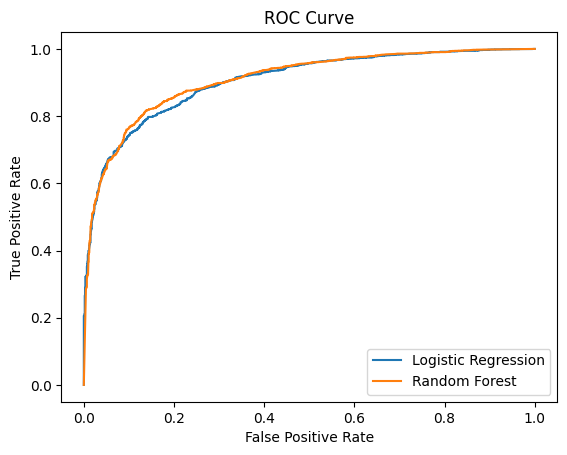

In [18]:
# 15. ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

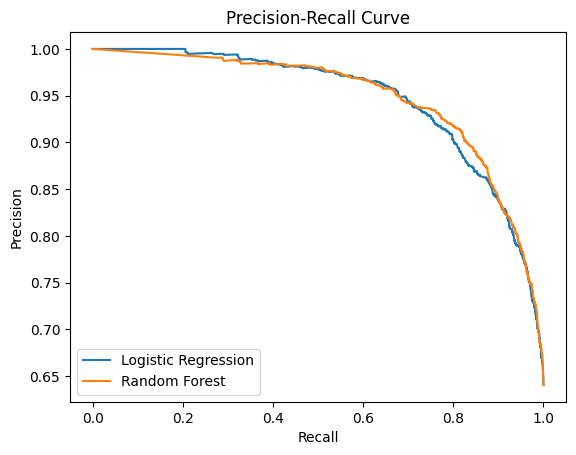

In [19]:
# 16. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(recall_lr, precision_lr, label="Logistic Regression")
plt.plot(recall_rf, precision_rf, label="Random Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

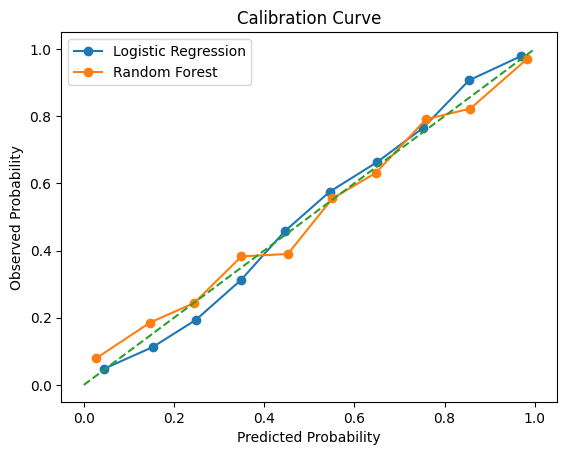

In [20]:
# 17. Calibration Curve
from sklearn.calibration import calibration_curve

prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10)

plt.figure()
plt.plot(prob_pred_lr, prob_true_lr, marker='o', label="Logistic Regression")
plt.plot(prob_pred_rf, prob_true_rf, marker='o', label="Random Forest")

# perfect calibration line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [21]:
import joblib

# Save models
joblib.dump(lr, 'logistic_regression.pkl')
joblib.dump(rf, 'random_forest.pkl')

# Save the tfidf vectorizer too — you'll need it to transform new input
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save structured feature columns too — needed to align new input
joblib.dump(X_structured.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']